In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
from scipy.io import arff
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, fbeta_score,
)
import math

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

## Model: Logistic Regression from scratch

In [2]:
def sigmoid(x):
    x = np.clip(x, -500, 500)  # To guard np.exp against overflow
    return 1/(1+np.exp(-x))

def compute_gradient(X, y, w, b, reg_param):
        """
        Args:
          X (ndarray (m,n))
          y (ndarray (m,))
          w (ndarray (n,))
          b (scalar)
        """
        
        m,n = X.shape
        f = sigmoid(X@w + b)
        diff = f - y
        dj_dw = (X.T @ diff) / m
        dj_dw += (reg_param / m) * w
        dj_db = diff.mean()
        
        return dj_dw, dj_db
                
def cost(X, y, w, b, reg_param):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(m,))
          w (ndarray(n,))
          b (scalar)
        """
        
        m = X.shape[0]
        f = sigmoid(X@w + b)
        f = np.clip(f, 1e-9, 1 - 1e-9)
        cost = -y*np.log(f) - (1-y)*np.log(1-f) 
        regularisation_term = (reg_param / (2*m)) * np.sum(w**2)
        return cost.mean() + regularisation_term

def gradient_descent(X, y, w_in, b_in, alpha, iterations, reg_param=0, show=True):
        """
        Args:
          X (ndarray(m,n))
          y (ndarray(n,))
          w (ndarray(n,))
          b (scalar)
          alpha (scalar)
          iterations (scalar)
        """
        
        J_history = []  
        w = copy.deepcopy(w_in)
        b = b_in
        for i in range(iterations):
                dj_dw, dj_db = compute_gradient(X, y, w, b, reg_param)
                w -= alpha*dj_dw
                b -= alpha*dj_db
                J = cost(X, y, w, b, reg_param)
                J_history.append(J)
                if i % math.ceil(iterations / 10) == 0 and show:
                        print(f"Iteration {i:4d}: Cost {J_history[i]}")
        return w, b, J_history

## Prediction & Evaluation helpers

In [23]:
def predict_proba(X, w, b):
    return sigmoid(X @ w + b)


def predict(X, w, b, threshold=0.5):
    return (predict_proba(X, w, b) >= threshold).astype(int)


def best_threshold_youden(X_cv, y_cv, w, b):
    """Threshold that maximises TPR - FPR (Youden's J) on the CV set."""
    fpr, tpr, thresholds = roc_curve(y_cv, predict_proba(X_cv, w, b))
    return thresholds[np.argmax(tpr - fpr)]


def evaluate(X, y, w, b, threshold=0.5, title=""):
    """Print report + F2, show confusion matrix. Returns the predictions."""
    preds = predict(X, w, b, threshold)
    print(f"--- {title} (threshold={threshold:.3f}) ---")
    print(f"accuracy: {(preds == y).mean():.4f}")
    print(classification_report(y, preds, target_names=["normal", "anomaly"]))
    print(f"F2-score: {fbeta_score(y, preds, beta=2):.4f}\n")
    cm = confusion_matrix(y, preds, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["normal", "anomaly"]).plot()
    plt.title(title)
    return preds

## Scaling
Per-feature: log1p for the heavy-tailed byte columns (4, 5), standardise the rest.

In [4]:
def fit_scaler(X, std_cols):
    mean = X[std_cols].mean()
    std  = np.clip(X[std_cols].std(), 1e-7, None)
    return mean, std

def apply_scaler(X, mean, std, std_cols, log_cols):
    scaled = X.copy()
    scaled[std_cols] = (X[std_cols] - mean) / std
    scaled[log_cols] = np.log1p(X[log_cols])
    return scaled

## Load & Encode NSL-KDD data
LabelEncoder fitted on train, applied to test. 
one-hot encoding applied to 'service' column.

In [6]:
train_data, _ = arff.loadarff('KDDTrain+.arff')
test_data, _ = arff.loadarff('KDDTest+.arff')
df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

# Decode bytes
for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode('utf-8')
        test_df[col] = test_df[col].str.decode('utf-8')

# Encode class column
cats = ['normal', 'anomaly']  # index 0 = normal, index 1 = anomaly
train_class    = pd.Categorical(df['class'], categories=cats).codes
test_class      = pd.Categorical(test_df['class'], categories=cats).codes

# one-hot encode categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')
ohe.fit(df[categorical_cols])

train_one_hot = ohe.transform(df[categorical_cols]); test_one_hot = ohe.transform(test_df[categorical_cols])
df = df.drop(categorical_cols + ['class'], axis=1)
test_df = test_df.drop(categorical_cols + ['class'], axis=1)

# Scale numeric columns
log_cols = ['src_bytes', 'dst_bytes']
standard_cols = [c for c in df.columns if c not in log_cols + ['class']]
df[standard_cols] = df[standard_cols].apply(pd.to_numeric, errors='coerce')
test_df[standard_cols] = test_df[standard_cols].apply(pd.to_numeric, errors='coerce')
mean, std = fit_scaler(df, standard_cols)
scaled_num_train_X = apply_scaler(df, mean, std, standard_cols, log_cols)
scaled_num_test_X  = apply_scaler(test_df, mean, std, standard_cols, log_cols)

# training sets below currently hold only numeric columns
train_X = df.to_numpy(dtype=float)
train_y = train_class
test_X = test_df.to_numpy(dtype=float)
test_y = test_class

# Stick one-hot encoded categorical columns back onto the numeric (scaled) columns
scaled_train_X = np.hstack((scaled_num_train_X, train_one_hot))
scaled_test_X  = np.hstack((scaled_num_test_X, test_one_hot))

# Take 20% of training set to form cross validation set
scaled_train_X, cv_X, train_y, cv_y = train_test_split(
    scaled_train_X, train_y, test_size=0.2, stratify=train_y, random_state=0
)

In [7]:
# Sanity check: do train and test X matrices have the same number of features?
print(scaled_train_X.shape, scaled_test_X.shape)

# Did the pd.to_numeric with 'coerce' flag create any NaNs?
print(np.isnan(scaled_train_X).sum(), np.isnan(scaled_test_X).sum())

(100778, 122) (22544, 122)
0 0


In [12]:
# init weights and biases...
w_in = np.random.random_sample(scaled_train_X[0].shape)
b_in = np.random.random_sample()
alpha = 0.1
iters = 1000

## Regularisation hyperparameter-tuning
Compare train vs CV loss for varying regularisation parameter values.

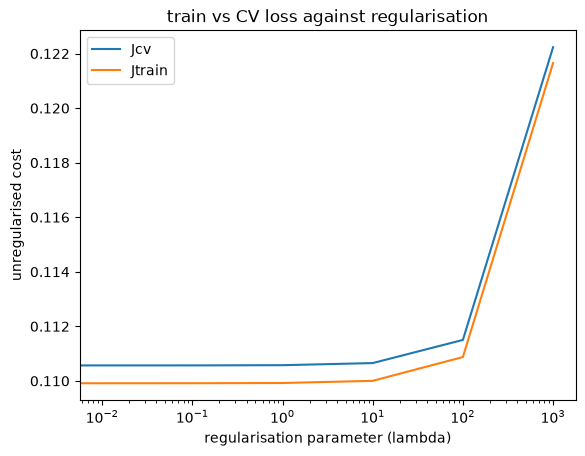

Optimal lambda = 0


In [13]:
# Use cross validation set to find optimal regularisation parameter out of a small set
lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000]
Jcv_history = []
Jtrain_history = []
for l in lambdas:
    w, b, _ = gradient_descent(scaled_train_X, train_y, w_in, b_in, alpha, iters, l, show=False)
    Jtrain_history.append(cost(scaled_train_X, train_y, w, b, 0))
    Jcv_history.append(cost(cv_X, cv_y, w, b, 0))

plt.plot(lambdas, Jcv_history, label='Jcv')
plt.plot(lambdas, Jtrain_history, label='Jtrain')
plt.xscale('log')
plt.xlabel("regularisation parameter (lambda)")
plt.ylabel("unregularised cost")
plt.title("train vs CV loss against regularisation")
plt.legend()
plt.show()

best_lambda = lambdas[int(np.argmin(Jcv_history))]
print(f"Optimal lambda = {best_lambda}")

## Final model + test eval
Threshold chosed on CV via Youden's J.
LAMBDA chosen from previous cell

In [14]:
# Sanity check: do train and test X matrices have the same number of features?
print(scaled_train_X.shape, scaled_test_X.shape)

# Did the pd.to_numeric with 'coerce' flag create any NaNs?
print(np.isnan(scaled_train_X).sum(), np.isnan(scaled_test_X).sum())

(100778, 122) (22544, 122)
0 0


Iteration    0: Cost 3.8857014152157996
Iteration  100: Cost 0.20769414468490893
Iteration  200: Cost 0.17822608135999904
Iteration  300: Cost 0.16101405890949158
Iteration  400: Cost 0.1507585649790742
Iteration  500: Cost 0.1437429070048969
Iteration  600: Cost 0.13846438360845467
Iteration  700: Cost 0.1345752923235518
Iteration  800: Cost 0.13148050414469203
Iteration  900: Cost 0.12893595841345695


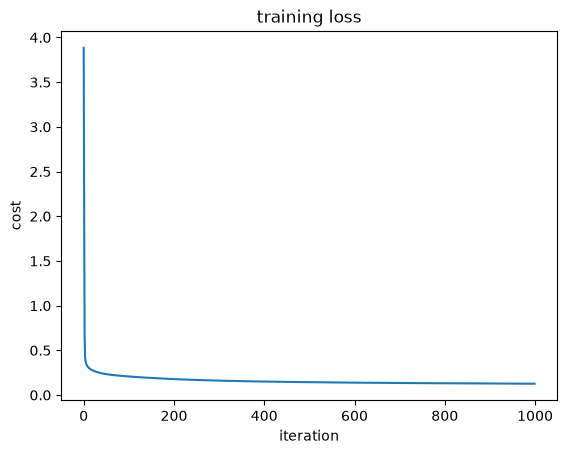

Youden's J threshold: 0.528
--- TRAIN {thr=0.5} (threshold=0.500) ---
accuracy: 0.9675
              precision    recall  f1-score   support

      normal       0.96      0.98      0.97     53874
     anomaly       0.97      0.96      0.96     46904

    accuracy                           0.97    100778
   macro avg       0.97      0.97      0.97    100778
weighted avg       0.97      0.97      0.97    100778

F2-score: 0.9598

--- TEST {thr=Youden's J} (threshold=0.528) ---
accuracy: 0.7515
              precision    recall  f1-score   support

      normal       0.65      0.93      0.76      9711
     anomaly       0.92      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544

F2-score: 0.6603



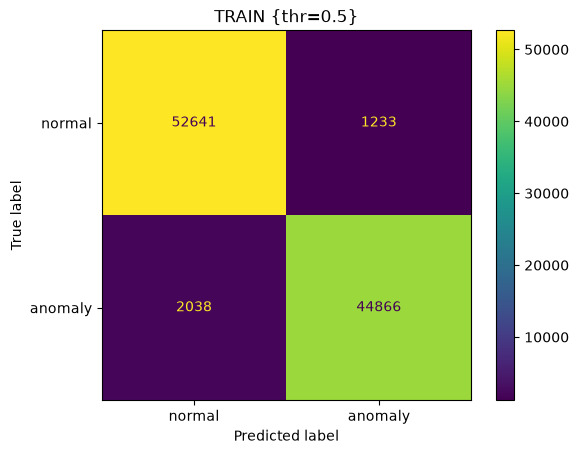

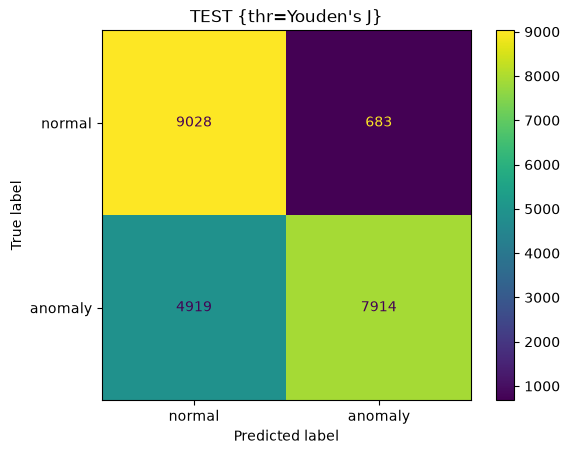

In [24]:
LAMBDA = 100
w, b, J_history = gradient_descent(scaled_train_X, train_y, w_in, b_in,
                                   alpha, iters, LAMBDA, show=True)
plt.plot(J_history)
plt.xlabel("iteration"); plt.ylabel("cost"); plt.title("training loss"); plt.show()

thr = best_threshold_youden(cv_X, cv_y, w, b)
print(f"Youden's J threshold: {thr:.3f}")

evaluate(scaled_train_X, train_y, w, b, threshold=0.5, title="TRAIN {thr=0.5}")
preds = evaluate(scaled_test_X, test_y, w, b, threshold=thr, title="TEST {thr=Youden's J}")

## Testing on seen vs. unseen attack types in the test set
NSL-KDD notoriously contains attack types in the test set that are not seen in the training set.
I want to quantify the difference in recall between attacks that are in the training set (seen) and attacks that aren't (unseen).

In [25]:
train_raw = pd.read_csv('KDDTrain+.txt', header=None)
test_raw  = pd.read_csv('KDDTest+.txt',  header=None)
train_attack = train_raw.iloc[:, 41]
test_attack  = test_raw.iloc[:, 41]
train_attacks = set(train_attack) - {'normal'}
test_attacks  = set(test_attack)  - {'normal'}
novel = test_attacks - train_attacks
print(f"{len(novel)} attack types in test but never in training:", novel)

17 attack types in test but never in training: {'httptunnel', 'xlock', 'xterm', 'sendmail', 'apache2', 'snmpgetattack', 'saint', 'xsnoop', 'named', 'worm', 'processtable', 'udpstorm', 'ps', 'sqlattack', 'mailbomb', 'mscan', 'snmpguess'}


In [26]:
def category(a):
    if a == 'normal':      return 'normal'
    if a in train_attacks: return 'seen_attack'
    return 'novel_attack'

test_category = test_attack.map(category)

In [28]:
for grp in ['seen_attack', 'novel_attack']:
    mask = (test_category == grp).to_numpy()
    caught = (preds[mask] == 1).mean()
    print(f"{grp}: recall = {caught:.3f} (n={mask.sum()})")
    

seen_attack: recall = 0.714 (n=9083)
novel_attack: recall = 0.380 (n=3750)


In [29]:
# Since we're taking the attack labels from the .txt and I stupidly started with .arff,
# this makes sure they ordered in the same way so the attack types i find in .txt align with predictions from .arff.
# Future Omar: maybe pay more attention to which data set you are downloading...
derived = (test_attack != 'normal').astype(int).to_numpy()
print("labels aligned:", (derived == test_y).all())

labels aligned: True
